# External test (HCP data)

This notebook evaluates the trained unsmooted brain age model on an independent external HCP test set. The external test subjects were not used during model training, validation, or internal testing.

The aim of this notebook is to assess how well the trained model generalizes to new, unseen HCP subjects. HCP data has the age range 22-35 years.

## Imports and setup

In [1]:
# Import the main fastMONAI functionality used for 3D medical imaging workflows
from fastMONAI.vision_all import *

# Import libraries
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import nibabel as nib
from monai.networks.nets import Regressor
from fastai.metrics import mae
from fastai.losses import L1LossFlat

## Paths

In [2]:
# Define paths for the external HCP test dataset
# These subjects were not included during model training, validation, or internal testing
data_dir = Path("/home/anneaasengen/fastMONAI/data_asymmetry")

# Folder containing the asymmetry maps used as input to the trained model
image_dir = data_dir / "asymmetry_images_external_test"

# Metadata file containing HCP subject IDs, age, and sex
hcp_csv  = data_dir / "HCP_participants.csv"

## Load metadata (HCP)

In [3]:
# Load metadata for the external HCP subjects
df_hcp = pd.read_csv(hcp_csv)

# Rename columns to match the naming convention used in the rest of the project
df_hcp = df_hcp.rename(columns={
    "Subject": "participant_id",
    "Age_in_Yrs": "age",
    "Gender": "sex"
})

# Make sure participant IDs are stored as strings, so they can be matched to filenames
df_hcp["participant_id"] = df_hcp["participant_id"].astype(str)

# Keep only the columns needed for the external test
df_hcp = df_hcp[['participant_id', 'age', 'sex']]

df_hcp.head()

,participant_id,age,sex
0,100004,24,M
1,100206,27,M
2,100307,27,F
3,100408,33,M
4,100610,27,M


## Build dataframe linking images to subject metadata

In [4]:
# Build a dataframe where each row represents one external HCP subject
# The dataframe links each asymmetry map to the corresponding participant ID, age, and sex
rows = []

for fname in sorted(image_dir.glob("AI_mwrp1sub-*_T1w_affine.nii")):
    # Extract the HCP subject ID from the image filename
    subject_id = fname.name.split("AI_mwrp1sub-")[1].split("_")[0]

    # Find the matching metadata row for this subject
    match = df_hcp[df_hcp["participant_id"] == subject_id]

    if len(match) == 1:
        rows.append({
            "image_path": str(fname),
            "participant_id": subject_id,
            "age": match["age"].values[0],
            "sex": match["sex"].values[0]
        })
    else:
        # Print a warning if an image does not have a corresponding metadata entry
        print("Did not find metadata for subject:", subject_id)

# Convert the collected rows into a dataframe 
df_ext = pd.DataFrame(rows)

# Check the number of available external test scans
print("Number of scans:", len(df_ext))

df_ext.head()

Number of scans: 150


,image_path,participant_id,age,sex
0,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-304020_T1w_affine.nii,304020,35,M
1,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-304727_T1w_affine.nii,304727,33,F
2,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-305830_T1w_affine.nii,305830,25,F
3,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-307127_T1w_affine.nii,307127,34,F
4,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-308129_T1w_affine.nii,308129,24,M


## MedDataset

In [5]:
# Create a MedDataset object from the external test images
# This is used to inspect the image files and obtain suitable preprocessing suggestions
med_dataset = MedDataset(path=image_dir, max_workers=8)


# Get suggested resampling and reorientation settings from the image dataset
# Using these settings helps ensure that the external HCP images are handled consistently
resample, reorder = med_dataset.suggestion()

## DataBlock

In [6]:
# Define the expected input shape for the trained 3D CNN
# The first dimension is the image channel, followed by the 3D spatial dimensions
in_shape = [1, 128, 160, 128]

# Use the same batch size as in the original training setup
bs = 4


# Define preprocessing applied to each external test image
item_tfms = [
    # Normalize voxel intensities within each image
    ZNormalization(),

    # Ensure all images have the same spatial dimensions expected by the model
    PadOrCrop(in_shape[1:])
]

# Define the external test DataBlock
# The inputs are 3D asymmetry maps, and the target variable is chronological age
dblock_ext = MedDataBlock(
    blocks=(ImageBlock(cls=MedImage), RegressionBlock),
    get_x=ColReader("image_path"),
    get_y=ColReader("age"),
    item_tfms=item_tfms,
    reorder=reorder,
    resample=resample)

## Dataloaders

In [7]:
# Create dataloaders from the external HCP dataframe
# No model training is performed here; the dataloaders are only used for inference/evaluation
dls_ext = dblock_ext.dataloaders(df_ext, bs=bs)

# Create a test dataloader that includes labels, so predictions can be compared with true ages
ext_test_dl = dls_ext.test_dl(df_ext, with_labels=True)

## Load baseline-model (already trained)

In [8]:
# Recreate the same model architecture that was used during training
# The architecture must match the saved model weights exactly
model = Regressor(
    in_shape=in_shape,
    out_shape=1,
    channels=(64, 128, 256, 256, 256),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    num_res_units=2
)

# Create a Learner object for evaluation
# The loss function and metric are the same as those used during model training
learn = Learner(
    dls_ext,
    model,
    loss_func=L1LossFlat(),
    metrics=[mae]
)

# Load the previously trained model (unsmoothed model)
# This model is evaluated on external HCP subjects that were not used during training
learn.load("baseline_best")

Saved file doesn't contain an optimizer state.


## Predictions

In [9]:
# Generate predictions for the external HCP test set
preds, targs = learn.get_preds(dl=ext_test_dl)

# Convert predictions and targets from tensors to NumPy arrays for further analysis
y_pred = preds.squeeze().cpu().numpy()
y_true = targs.squeeze().cpu().numpy()

## External MAE (raw)

In [10]:
# Calculate the raw prediction error for each subject
# Positive values mean that the model predicted an older brain age than the chronological age
error = y_pred - y_true

# Compute mean absolute error (MAE) on the external HCP test set
# This gives the average absolute difference between predicted and chronological age
mae_external = np.mean(np.abs(error))

print(f"External HCP test-MAE (raw): {mae_external:.3f}")

External HCP test-MAE (raw): 3.004


## Sanity checks

In [11]:
# Basic sanity checks for the external test predictions
print("Number of samples:", len(y_true))

# Check the chronological age range in the external HCP dataset
print("True age range:", y_true.min(), y_true.max())

# Check the range of predicted ages produced by the model
print("Pred age range:", y_pred.min(), y_pred.max())

Number of samples: 150
True age range: 22.0 35.0
Pred age range: 23.935825 35.055862


## Bias correction

In [12]:
# Load the bias correction parameters estimated from the training data
# These parameters are used to adjust predictions for the common brain age bias
# where younger subjects tend to be overestimated and older subjects underestimated

a, b = np.load("bias_correction_params.npy")
print(f"Loaded bias correction parameters: a = {a:.4f}, b = {b:.4f}")

Loaded bias correction parameters: a = 1.0120, b = -0.8515


In [13]:
# Apply the linear bias correction to the external HCP predictions
# The correction uses parameters estimated from the training data, not from the external test set
y_pred_bc = (y_pred - b) / a

# Brain age gap (BAG) is defined as predicted age minus chronological age
bag_raw = error # rename
bag_bc  = y_pred_bc - y_true

In [14]:
# Compare raw and bias-corrected MAE on the external HCP test set
mae_raw = mae_external #rename
mae_bc  = np.mean(np.abs(bag_bc))

print(f"External HCP test-MAE (raw): {mae_raw:.3f}")
print(f"External HCP test-MAE (bias-corrected): {mae_bc:.3f}")

External HCP test-MAE (raw): 3.004
External HCP test-MAE (bias-corrected): 3.078


In [15]:
# Store predictions and brain age gap values in the external test dataframe
df_ext = df_ext.copy()
df_ext["predicted_age"] = y_pred
df_ext["predicted_age_bc"] = y_pred_bc
df_ext["brain_age_gap"] = bag_raw
df_ext["brain_age_gap_bc"] = bag_bc

df_ext.head()

,image_path,participant_id,age,sex,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc
0,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-304020_T1w_affine.nii,304020,35,M,31.987242,32.449262,-3.012758,-2.550738
1,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-304727_T1w_affine.nii,304727,33,F,29.354813,29.848053,-3.645187,-3.151947
2,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-305830_T1w_affine.nii,305830,25,F,31.661337,32.127223,6.661337,7.127223
3,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-307127_T1w_affine.nii,307127,34,F,29.374161,29.867172,-4.625839,-4.132828
4,/home/anneaasengen/fastMONAI/data_asymmetry/asymmetry_images_external_test/AI_mwrp1sub-308129_T1w_affine.nii,308129,24,M,25.789921,26.325440,1.789921,2.325440


## Plot: True age vs predicted age

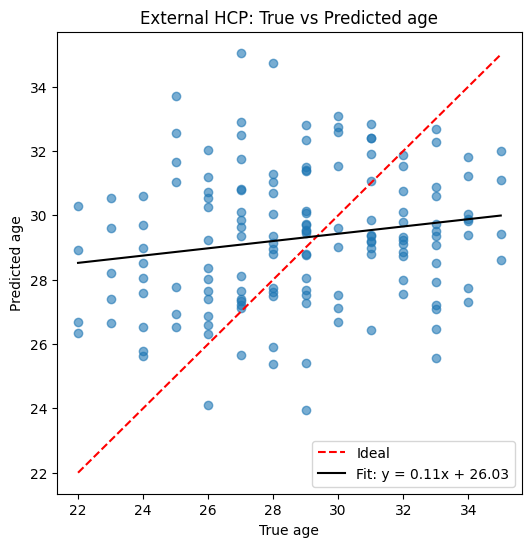

In [16]:
# Plot chronological age against raw predicted age
# The dashed identity line represents perfect prediction
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)

# Define x-values for the identity line and fitted regression line
x = np.linspace(y_true.min(), y_true.max(), 100)

# Plot the ideal prediction line where predicted age equals chronological age
plt.plot(x, x, 'r--', label="Ideal")

# Fit and plot a regression line to show the relationship between true and predicted age
coef = np.polyfit(y_true, y_pred, 1)
plt.plot(x, coef[0]*x + coef[1], 'k-', 
         label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}")

plt.xlabel("True age")
plt.ylabel("Predicted age")
plt.title("External HCP: True vs Predicted age")
plt.legend()
plt.show()

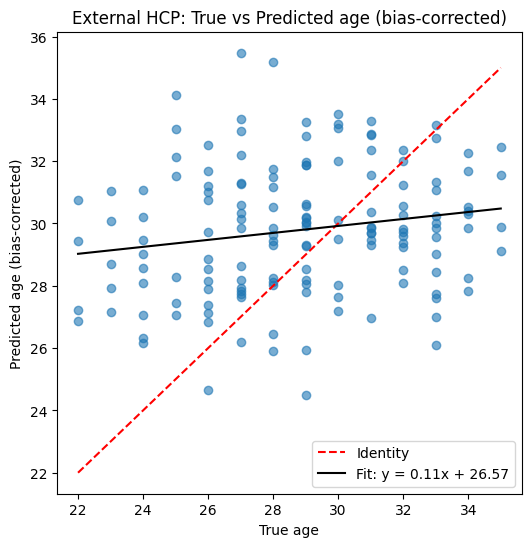

In [17]:
# Plot chronological age against bias-corrected predicted age
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_bc, alpha=0.6)

# Plot the ideal prediction line
plt.plot(x, x, 'r--', label="Identity")

# Fit and plot a regression line for the bias-corrected predictions
coef_bc = np.polyfit(y_true, y_pred_bc, 1)
plt.plot(x, coef_bc[0]*x + coef_bc[1], 'k-', 
         label=f"Fit: y = {coef_bc[0]:.2f}x + {coef_bc[1]:.2f}")

plt.xlabel("True age")
plt.ylabel("Predicted age (bias-corrected)")
plt.title("External HCP: True vs Predicted age (bias-corrected)")
plt.legend()
plt.show()

## Plot: Brain age gap vs age

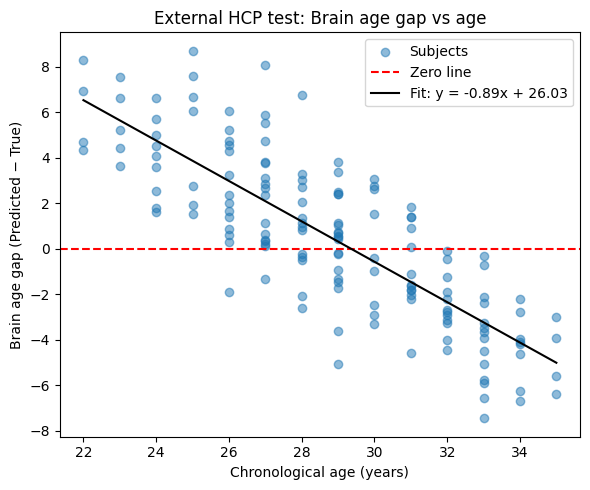

In [18]:
# Plot raw brain age gap as a function of chronological age
plt.figure(figsize=(6,5))
plt.scatter(y_true, bag_raw, alpha=0.5, label="Subjects")

# The zero line indicates perfect agreement between predicted and chronological age
plt.axhline(0, color="red", linestyle="--", label="Zero line")

# Fit a linear trend to assess age-related bias in the raw BAG values
coef_bag = np.polyfit(y_true, bag_raw, 1)

plt.plot(
    x,
    coef_bag[0]*x + coef_bag[1],
    'k-',
    label=f"Fit: y = {coef_bag[0]:.2f}x + {coef_bag[1]:.2f}"
)

plt.xlabel("Chronological age (years)")
plt.ylabel("Brain age gap (Predicted − True)")
plt.title("External HCP test: Brain age gap vs age")
plt.legend()
plt.tight_layout()
plt.show()

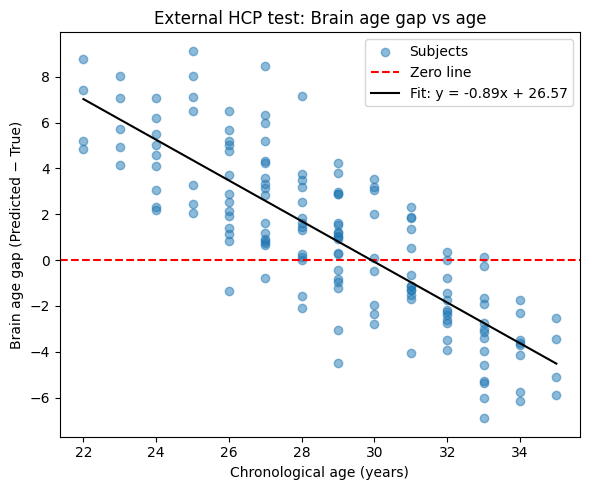

In [19]:
# Plot bias-corrected brain age gap as a function of chronological age
plt.figure(figsize=(6,5))
plt.scatter(y_true, bag_bc, alpha=0.5, label="Subjects")

# The zero line indicates no brain age gap
plt.axhline(0, color="red", linestyle="--", label="Zero line")

# Fit a linear trend to the bias-corrected BAG values
coef_bag_bc = np.polyfit(y_true, bag_bc, 1)

plt.plot(
    x,
    coef_bag_bc[0]*x + coef_bag_bc[1],
    'k-',
    label=f"Fit: y = {coef_bag_bc[0]:.2f}x + {coef_bag_bc[1]:.2f}"
)

plt.xlabel("Chronological age (years)")
plt.ylabel("Brain age gap (Predicted − True)")
plt.title("External HCP test: Brain age gap vs age")
plt.legend()
plt.tight_layout()
plt.show()

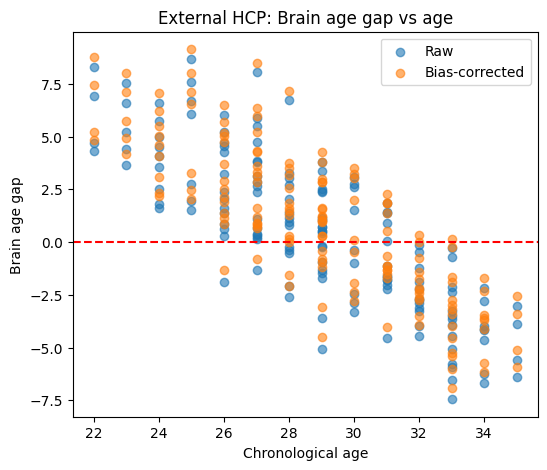

In [20]:
# Compare raw and bias-corrected brain age gap in the same plot
# This visualizes how the bias correction changes the distribution of BAG values
plt.figure(figsize=(6,5))
plt.scatter(y_true, bag_raw, alpha=0.6, label="Raw")
plt.scatter(y_true, bag_bc, alpha=0.6, label="Bias-corrected")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Chronological age")
plt.ylabel("Brain age gap")
plt.title("External HCP: Brain age gap vs age")
plt.legend()
plt.show()